In [2]:
import numpy as np
import matplotlib.pyplot as plt

from dynprolib.pyfriendly import (
    PortfolioChoiceModel,
    PortfolioConfig,
    compute_policy_grid_local,
    plot_policy_function,
    plot_value_function,
    solve_model_coefficients,
)

np.set_printoptions(precision=5, suppress=True)

Value iteration converged in 549 iterations
Final Bellman sup-norm error: 9.630e-07
State grid size: 250, action grid size: 66


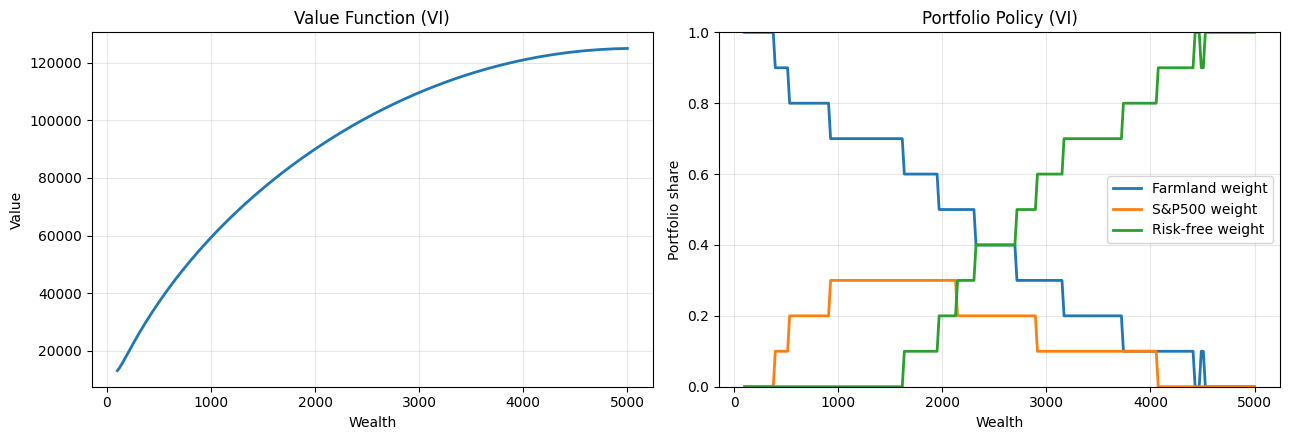

In [3]:
# Quick solve + diagnostics (aligned with Dynamic-Programming-Project workflow)
cfg = PortfolioConfig(
    beta=0.96,
    theta=0.0,
    b=60_000.0,
    wealth_min=100.0,
    wealth_max=5_000.0,
    wealth_size=250,
    action_grid_step=0.1,
    risk_free_gross=1.03,
    data_dir="Data",
)

model = PortfolioChoiceModel(config=cfg)
V_vi, pol_vi, iters_vi, hist_vi = model.value_iteration(
    tol=1e-6,
    max_iter=2_000,
    return_history=True,
)

print(f"Value iteration converged in {iters_vi} iterations")
print(f"Final Bellman sup-norm error: {hist_vi[-1]:.3e}")
print(f"State grid size: {model.state_size}, action grid size: {model.action_size}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_value_function(model, V_vi, ax=axes[0], title="Value Function (VI)")
plot_policy_function(model, pol_vi, ax=axes[1], title="Portfolio Policy (VI)")
plt.tight_layout()
plt.show()

# Optional benchmark: policy iteration is much slower for this notebook setup.
run_policy_iteration = False
if run_policy_iteration:
    V_pi, pol_pi, iters_pi = model.policy_iteration(tol=1e-6, max_iter=50)
    policy_gap = np.max(np.abs(model.actions[pol_vi] - model.actions[pol_pi]))
    print(f"Policy iteration converged in {iters_pi} iterations")
    print(f"Max difference between VI and PI chosen weights: {policy_gap:.3e}")

In [45]:
# Replicate x_t^* vs P_t using shared library code.
cfg_struct = PortfolioConfig()
cfg_struct.n = (7, 7, 5, 21)
cfg_struct.q = 41
cfg_struct.qf = 21
cfg_struct.m = (5, 5)
cfg_struct.T = 19
cfg_struct.t1 = 1
cfg_struct.smaxv =(540.0, 3540.0, 2000.0, 6_000_000.0)
cfg_struct.sminv = (230.0, 500.0, 400.0, 0.0)

copt_local = solve_model_coefficients(cfg_struct)
W = np.array([1_000_000.0, 500_000.0, 350_000.0])
policy = compute_policy_grid_local(copt_local, cfg_struct, t=0, Lt=600.0, Rt=365.0, wealth_levels=W)

P = policy["P"]
XP = policy["XP"]



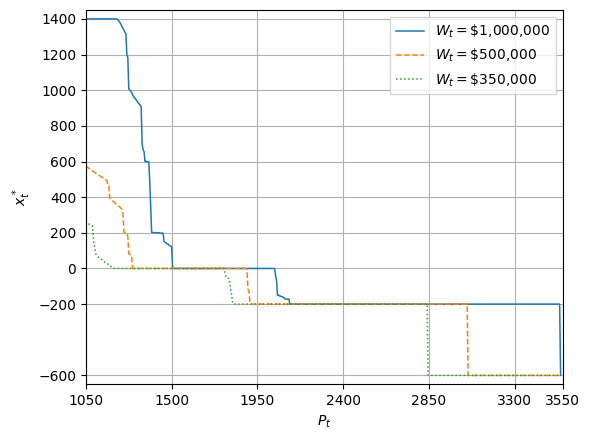

In [52]:
fig, ax = plt.subplots(figsize=(6.0, 4.5))
ax.plot(P, XP[:, 0], "-", linewidth=1.1, label=r"$W_t = \$1{,}000{,}000$")
ax.plot(P, XP[:, 1], "--", linewidth=1.1, label=r"$W_t = \$500{,}000$")
ax.plot(P, XP[:, 2], ":", linewidth=1.1, label=r"$W_t = \$350{,}000$")

ax.set_xlim(1050, 3550)
ax.set_ylim(-650, 1450)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850, 3300, 3550])
ax.set_yticks([-600, -200, 0, 200, 400, 600, 800, 1000, 1200, 1400])
ax.legend(loc="upper right", frameon=True, fancybox=False)
ax.grid(True)
plt.tight_layout()
plt.savefig("portfolio_policy_vs_price.png", dpi=300)
plt.show()

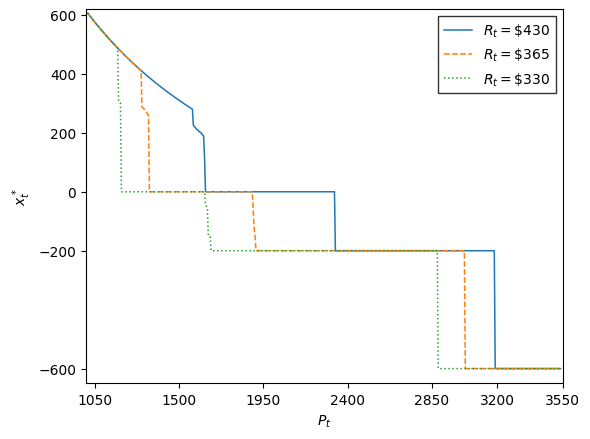

In [43]:
# Replicate x_t^* vs P_t for different R_t values (notebook-only functions).
W_fixed = np.array([500_000.0])
R_values = [430.0, 365.0, 330.0]
styles = ["-", "--", ":"]
labels = [r"$R_t = \$430$", r"$R_t = \$365$", r"$R_t = \$330$"]

curves = []
P_plot = None
for Rt in R_values:
    policy_rt = compute_policy_grid_local(
        copt_local,
        cfg_struct,
        t=0,
        Lt=600.0,
        Rt=Rt,
        wealth_levels=W_fixed,
    )
    if P_plot is None:
        P_plot = policy_rt["P"]
    curves.append(policy_rt["XP"][:, 0])

fig, ax = plt.subplots(figsize=(6.0, 4.5))
for y, style, label in zip(curves, styles, labels):
    ax.plot(P_plot, y, style, linewidth=1.1, label=label)

ax.set_xlim(1000, 3550)
ax.set_ylim(-650, 620)
ax.set_xlabel(r"$P_t$")
ax.set_ylabel(r"$x_t^*$")
ax.set_xticks([1050, 1500, 1950, 2400, 2850, 3200, 3550])
ax.set_yticks([-600, -200, 0, 200, 400, 600])
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
ax.grid(False)
plt.tight_layout()
plt.savefig("portfolio_policy_vs_price_Rt.png", dpi=300)
plt.show()

In [6]:
import numpy as np
import pandas as pd
from IPython.display import display

from dynprolib.pyfriendly import (
    PortfolioConfig,
    build_model_arrays,
    choose_value_maximizer,
    gauss_hermite_multinormal,
    get_value_maximizer,
    solve_model_coefficients,
    transition_next_state,
)

# Generate Table 5 by simulation.
# This mirrors the MATLAB pathT.m bookkeeping: farms exit irreversibly,
# exited farms stay in the sample, and the exit probability is cumulative.
rng = np.random.default_rng(2026)
n_sims = 500
n_years = 10

try:
    cfg_struct
except NameError:
    cfg_struct = PortfolioConfig()
    cfg_struct.n = (7, 7, 5, 21)
    cfg_struct.q = 41
    cfg_struct.qf = 21
    cfg_struct.m = (5, 5)
    cfg_struct.T = 19
    cfg_struct.t1 = 1

try:
    copt_local
except NameError:
    copt_local = solve_model_coefficients(cfg_struct)

arrays = build_model_arrays(cfg_struct)
n = arrays["n"]
sminv = arrays["sminv"]
smaxv = arrays["smaxv"]
smin = arrays["smin"]
smax = arrays["smax"]
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
value_maximizer = get_value_maximizer(choose_value_maximizer(cfg_struct))
EgRM = 1.073826

scenario_specs = [
    ("Initial DFA = 0.7", 350_000.0),
    ("Initial DFA = 0.57", 500_000.0),
    ("Initial DFA = 0.14", 1_000_000.0),
]

all_series = []
for scenario_name, initial_wealth in scenario_specs:
    states = np.zeros((n_sims, 4), dtype=float)
    states[:, 0] = 365.0
    states[:, 1] = 1775.0
    states[:, 2] = 600.0
    states[:, 3] = initial_wealth
    exited = np.zeros(n_sims, dtype=bool)

    rows = [
        {
            "Expected net wealth ($)": states[:, 3].mean(),
            "Expected farm size (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": 0.0,
        }
    ]

    for year in range(1, n_years + 1):
        # MATLAB pathT.m uses yr=0..years-1 with c1=copt(:,yr+1),
        # which maps to Python copt[:, yr] and value-maximizer time index yr.
        yr_idx = year - 1
        coeffs_t = copt_local[:, yr_idx]

        active_idx = np.where(~exited)[0]
        if active_idx.size > 0:
            active_states = states[active_idx]
            x_opt, _ = value_maximizer(
                active_states,
                coeffs_t,
                yr_idx,
                cfg_struct,
                n,
                sminv,
                smaxv,
                smin,
                smax,
                shock_nodes,
                shock_weights,
            )

            shocks = rng.multivariate_normal(
                mean=np.asarray(arrays["Ee"], dtype=float),
                cov=np.asarray(arrays["VarCov"], dtype=float),
                size=active_idx.size,
            )
            next_active = transition_next_state(
                active_states, x_opt, shocks, cfg_struct, sminv, smaxv
            )
            new_exit = (next_active[:, 2] < 1.0) | (next_active[:, 3] <= 0.0)
            states[active_idx] = next_active
            exited[active_idx[new_exit]] = True

        if np.any(exited):
            exited_idx = np.where(exited)[0]
            positive_wealth = states[exited_idx, 3] > 0.0
            states[exited_idx, 2] = 0.0
            states[exited_idx[positive_wealth], 3] = EgRM * states[exited_idx[positive_wealth], 3]
            states[exited_idx[~positive_wealth], 3] = (1.0 + cfg_struct.rn) * states[exited_idx[~positive_wealth], 3]

        cumulative_exit = exited.mean()

        rows.append(
            {
                "Expected net wealth ($)": states[:, 3].mean(),
                "Expected farm size (acres)": states[:, 2].mean(),
                "Prob. of exiting farming": cumulative_exit,
            }
        )

    scenario_df = pd.DataFrame(rows, index=pd.Index(range(n_years + 1), name="Year t"))
    scenario_df.columns = pd.MultiIndex.from_product([[scenario_name], scenario_df.columns])
    all_series.append(scenario_df)


table5 = pd.concat(all_series, axis=1)

display_table5 = table5.copy()
for scenario_name, _ in scenario_specs:
    display_table5[(scenario_name, "Expected net wealth ($)")] = display_table5[(scenario_name, "Expected net wealth ($)")].map(lambda v: f"{v:,.0f}")
    display_table5[(scenario_name, "Expected farm size (acres)")] = display_table5[(scenario_name, "Expected farm size (acres)")].map(lambda v: f"{v:,.0f}")
    display_table5[(scenario_name, "Prob. of exiting farming")] = display_table5[(scenario_name, "Prob. of exiting farming")].map(lambda v: f"{v:.3f}")

print("Table 5. Simulation results of expected path and probabilities of exiting farming")
display(display_table5)


Table 5. Simulation results of expected path and probabilities of exiting farming


Initial DFA = 0.7                             \
       Expected net wealth ($) Expected farm size (acres)   
Year t                                                      
0                      350,000                        600   
1                      383,776                        600   
2                      403,673                        516   
3                      436,166                        498   
4                      478,508                        504   
5                      520,643                        520   
6                      578,111                        542   
7                      632,591                        560   
8                      686,806                        582   
9                      752,271                        623   
10                     814,499                        634   

                                     Initial DFA = 0.57  \
       Prob. of exiting farming Expected net wealth ($)   
Year t                                                    
0                         0.000                 500,000   
1                         0.000                 540,756   
2                         0.006                 579,678   
3                         0.010                 630,279   
4                         0.022                 683,104   
5                         0.034                 736,920   
6                         0.044                 790,496   
7                         0.064                 862,580   
8                         0.084                 957,334   
9                         0.098               1,044,661   
10                        0.114               1,155,404   

                                                            \
       Expected farm size (acres) Prob. of exiting farming   
Year t                                                       
0                             600                    0.000   
1                             600                    0.000   
2                             548                    0.000   
3                             557                    0.000   
4                             581                    0.000   
5                             631                    0.002   
6                             666                    0.006   
7                             707                    0.006   
8                             761                    0.012   
9                             803                    0.016   
10                            837                    0.024   

            Initial DFA = 0.14                             \
       Expected net wealth ($) Expected farm size (acres)   
Year t                                                      
0                    1,000,000                        600   
1                    1,070,580                        600   
2                    1,136,660                        721   
3                    1,229,565                        870   
4                    1,324,170                        984   
5                    1,434,246                      1,025   
6                    1,577,856                      1,100   
7                    1,722,070                      1,148   
8                    1,853,338                      1,182   
9                    1,995,269                      1,188   
10                   2,147,284                      1,203   

                                 
       Prob. of exiting farming  
Year t                           
0                         0.000  
1                         0.000  
2                         0.000  
3                         0.000  
4                         0.000  
5                         0.000  
6                         0.000  
7                         0.000  
8                         0.000  
9                         0.000  
10                        0.002

In [12]:
!pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [16]:
# Save the formatted table to a LaTeX file.
tex_path = "table5.tex"

# Requires \usepackage{makecell} in your LaTeX preamble.
metric_makecell = {
    "Expected net wealth ($)": r"\makecell{Expected net\\wealth (\$)}",
    "Expected farm size (acres)": r"\makecell{Expected farm\\size (acres)}",
    "Prob. of exiting farming": r"\makecell{Prob. of exiting\\farming}",
}

table5_makecell = display_table5.copy()
table5_makecell.columns = pd.MultiIndex.from_tuples(
    [(top, metric_makecell.get(sub, sub)) for top, sub in table5_makecell.columns]
)

table5_makecell.to_latex(
    tex_path,
    escape=False,
    multicolumn=True,
    multirow=True,
    index=True
)

print(f"Saved LaTeX table to {tex_path}")

Saved LaTeX table to table5.tex


# Table 7 without mutual

In [ ]:
import numpy as np
import pandas as pd

from dynprolib.pyfriendly.portfolio_core import (
    PortfolioConfig,
    build_model_arrays,
    choose_value_maximizer,
    evaluate_trade_grid_coarse,
    evaluate_trade_grid_fine,
    feasible_trade_bounds,
    gauss_hermite_multinormal,
    get_value_maximizer,
    solve_model_coefficients,
)

# Table 7 replication (WITHOUT mutual fund) using the solver path.
# Paper specification: theta = 1.

cfg_table7 = PortfolioConfig()
cfg_table7.theta = 1.0
cfg_table7.n = (7, 7, 5, 21)
cfg_table7.q = 41
cfg_table7.qf = 21
cfg_table7.m = (5, 5)
cfg_table7.T = 19
cfg_table7.t1 = 1

copt_table7 = solve_model_coefficients(cfg_table7)
arrays = build_model_arrays(cfg_table7)
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
value_maximizer = get_value_maximizer(choose_value_maximizer(cfg_table7))

def debt_to_farm_asset_ratio(P, L, W, tcs=0.06, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    lafa = (W / (pps * L)) - 1.0
    return max(0.0, -lafa)

def resulting_dfa_after_trade(P, L, W, x, tcs=0.06, tcb=0.01, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    ppps = (1.0 + tcb) * P + fme
    if x < 0:
        ppps = pps
    L_post = L + x
    if L_post <= 0.0:
        return 0.0
    lafa12f = (W - pps * L - ppps * x) / (pps * L_post)
    return max(0.0, -lafa12f)

Lt = 600.0
Rt = 365.0
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
rows = []
for P in prices:
    for W in wealth_levels:
        state = np.array([[Rt, P, Lt, W]], dtype=float)
        x_opt, _ = value_maximizer(
            state,
            copt_table7[:, 0],
            0,
            cfg_table7,
            arrays["n"],
            arrays["sminv"],
            arrays["smaxv"],
            arrays["smin"],
            arrays["smax"],
            shock_nodes,
            shock_weights,
        )
        x_star = float(x_opt[0])
        rows.append(
            {
                "Current farmland price ($)": int(P),
                "Net wealth ($)": int(W),
                "Debt-to-farm-asset ratio": debt_to_farm_asset_ratio(P, Lt, W),
                "Optimal farmland transaction (acres)": x_star,
                "Resulting debt-to-farm-asset ratio": resulting_dfa_after_trade(P, Lt, W, x_star),
            }
        )

table7_without_mutual = pd.DataFrame(rows)
display_table7 = table7_without_mutual.copy()
display_table7["Net wealth ($)"] = display_table7["Net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table7["Debt-to-farm-asset ratio"] = display_table7["Debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")
display_table7["Optimal farmland transaction (acres)"] = display_table7["Optimal farmland transaction (acres)"].map(lambda v: f"{v:,.0f}")
display_table7["Resulting debt-to-farm-asset ratio"] = display_table7["Resulting debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")

print("Table 7 - Model without mutual fund (simulation-based policy evaluation, theta=1)")
display(display_table7)


Table 7 - Model without mutual fund (simulation-based policy evaluation, theta=1)


,Current farmland price ($),Net wealth ($),Debt-to-farm-asset ratio,Optimal farmland transaction (acres),Resulting debt-to-farm-asset ratio
0,1500,"400,000",0.61,-200,0.41
1,1500,"600,000",0.41,0,0.41
2,1500,"1,000,000",0.01,0,0.01
3,1775,"400,000",0.66,-200,0.49
4,1775,"600,000",0.49,-200,0.23
5,1775,"1,000,000",0.14,0,0.14



Diagnostics for the target states
P=1500, W=400000: x_low=-200.0, x_high=151.7, coarse_best=-200.0 (v=13.8573), fine_best=-200.0 (v=13.8573)
P=1500, W=600000: x_low=-200.0, x_high=467.8, coarse_best=0.3 (v=14.6375), fine_best=0.0 (v=14.6376)
P=1775, W=400000: x_low=-200.0, x_high=67.8, coarse_best=-200.0 (v=13.5668), fine_best=-200.0 (v=13.5668)
P=1775, W=600000: x_low=-200.0, x_high=341.9, coarse_best=-200.0 (v=14.3463), fine_best=-200.0 (v=14.3463)
